# Earliest Click Predictors

The convergence analysis (Notebook 1) shows mouse-gaze distance converging in the last ~5-10s before click. But the norm isn't the interesting part — the *exceptions* are. What are the earliest detectable signals that a click is coming?

**Candidate early signals:**
1. **First fixation revisit** — the eye returns to a result it already scanned. This is the fixation-level precursor to a scroll regression.
2. **Scroll deceleration** — the scroll slows before stopping. The deceleration profile may predict which viewport-lock leads to a click vs. continued scanning.
3. **Mouse drift onset** — the mouse begins moving toward the eventual click Y, even before the viewport settles.
4. **Gaze dwell accumulation** — total fixation time on the eventual click target crosses a threshold.

**Why this matters:** If the earliest predictor is 15-20s before click (during initial scan), it means the decision process begins much earlier than the motor convergence suggests. The user may identify the target peripherally or in a brief fixation, continue scanning to confirm there's nothing better, then return.

In [1]:
import os
import csv
import xml.etree.ElementTree as ET
import math
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 150,
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

DATA_DIR = 'AdSERP/data'
FIXATION_DIR = os.path.join(DATA_DIR, 'fixation-data')
MOUSE_DIR = os.path.join(DATA_DIR, 'mouse-movement-data')
METADATA_DIR = os.path.join(DATA_DIR, 'trial-metadata')

trial_ids = sorted(f.replace('.csv', '') for f in os.listdir(FIXATION_DIR) if f.endswith('.csv'))
print(f"Trials: {len(trial_ids)}")

Trials: 2776


In [2]:
def load_trial_full(tid):
    """Load fixations, mouse+scroll, click position for one trial."""
    # Metadata
    meta_path = os.path.join(METADATA_DIR, f'{tid}.xml')
    tree = ET.parse(meta_path)
    root = tree.getroot()
    win = root.find('window').text.split('x')
    win_w, win_h = int(win[0]), int(win[1])
    rx, ry = 1280 / win_w, 1024 / win_h
    
    # Fixations (page-space)
    fixes = []
    with open(os.path.join(FIXATION_DIR, f'{tid}.csv')) as f:
        for r in csv.DictReader(f):
            fixes.append({
                't': int(float(r['timestamp'])),
                'x': int(float(r['FPOGX'])),
                'y': int(float(r['FPOGY'])),
                'd': int(float(r['FPOGD'])),
            })
    
    # Mouse + scroll + click
    moves = []
    scrolls = []
    click_t = None
    click_x = click_y = None
    with open(os.path.join(MOUSE_DIR, f'{tid}.csv')) as f:
        for r in csv.DictReader(f):
            t = int(float(r['timestamp']))
            if r['event'] == 'click':
                click_t = t
                click_x = int(float(r['xpos'])) * rx
                click_y = int(float(r['ypos'])) * ry
            if r['event'] in ('mousemove', 'mouseover'):
                moves.append({'t': t, 'x': int(float(r['xpos'])) * rx, 'y': int(float(r['ypos'])) * ry})
            if r['event'] == 'scroll':
                scrolls.append((t, float(r['ypos'])))
    
    if click_t is None or len(fixes) < 5:
        return None
    
    # Click page-space Y
    click_scroll = 0.0
    for st, sy in scrolls:
        if st <= click_t:
            click_scroll = sy
    click_page_y = click_y + click_scroll if click_y else None
    
    return {
        'fixes': fixes, 'moves': moves, 'scrolls': scrolls,
        'click_t': click_t, 'click_x': click_x, 'click_page_y': click_page_y,
    }

def get_scroll_at(t, scrolls):
    offset = 0.0
    for st, sy in scrolls:
        if st <= t:
            offset = sy
        else:
            break
    return offset

def analyze_early_signals(tid):
    """For one trial, find the earliest signals pointing to the click target."""
    data = load_trial_full(tid)
    if data is None or data['click_page_y'] is None:
        return None
    
    fixes = data['fixes']
    click_t = data['click_t']
    click_page_y = data['click_page_y']
    scrolls = data['scrolls']
    moves = data['moves']
    
    trial_start = fixes[0]['t']
    trial_dur = (click_t - trial_start) / 1000.0
    if trial_dur < 3:
        return None
    
    # Define "near the click target" as within 150px vertically in page-space
    # (~1 result slot on a SERP)
    TARGET_RADIUS_Y = 150
    
    # 1. First fixation near the click target
    first_fix_near_target_ttc = None
    fix_visits_to_target = []
    for fix in fixes:
        if fix['t'] >= click_t:
            continue
        # Fixation is already in page-space
        if abs(fix['y'] - click_page_y) < TARGET_RADIUS_Y:
            ttc = (click_t - fix['t']) / 1000.0
            fix_visits_to_target.append(ttc)
            if first_fix_near_target_ttc is None:
                first_fix_near_target_ttc = ttc
    
    # 2. First fixation REVISIT near target (second visit after looking away)
    first_revisit_ttc = None
    in_target = False
    left_target = False
    for fix in fixes:
        if fix['t'] >= click_t:
            continue
        near = abs(fix['y'] - click_page_y) < TARGET_RADIUS_Y
        if near and not in_target:
            if left_target:
                # This is a revisit
                first_revisit_ttc = (click_t - fix['t']) / 1000.0
                break
            in_target = True
        elif not near and in_target:
            in_target = False
            left_target = True
    
    # 3. Mouse drift onset — first mouse move toward click target Y
    # (mouse page-space Y within 200px of click page-space Y)
    first_mouse_near_ttc = None
    for m in moves:
        if m['t'] >= click_t:
            continue
        scroll = get_scroll_at(m['t'], scrolls)
        mouse_page_y = m['y'] + scroll
        if abs(mouse_page_y - click_page_y) < 200:
            first_mouse_near_ttc = (click_t - m['t']) / 1000.0
            break
    
    # 4. Last scroll-stop before click (when viewport settles on target)
    last_scroll_stop_ttc = None
    if scrolls:
        for i in range(len(scrolls) - 1):
            gap = scrolls[i+1][0] - scrolls[i][0]
            if gap > 1000:  # >1s pause = scroll stop
                # Check if viewport contains target at this stop
                scroll_y = scrolls[i][1]
                if scroll_y <= click_page_y <= scroll_y + 1024:
                    last_scroll_stop_ttc = (click_t - scrolls[i][0]) / 1000.0
    
    return {
        'trial': tid,
        'trial_dur': trial_dur,
        'first_fix_near_target': first_fix_near_target_ttc,
        'first_revisit': first_revisit_ttc,
        'first_mouse_near': first_mouse_near_ttc,
        'last_scroll_stop_on_target': last_scroll_stop_ttc,
        'n_fix_visits': len(fix_visits_to_target),
    }

# Process all trials
print("Analyzing early click signals...")
signals = []
for i, tid in enumerate(trial_ids):
    if (i+1) % 500 == 0:
        print(f"  {i+1}/{len(trial_ids)}...")
    try:
        s = analyze_early_signals(tid)
        if s:
            signals.append(s)
    except:
        pass

print(f"\nAnalyzed {len(signals)} trials")
print(f"Trials with first fixation near target: {sum(1 for s in signals if s['first_fix_near_target'])}")
print(f"Trials with revisit to target: {sum(1 for s in signals if s['first_revisit'])}")
print(f"Trials with mouse near target: {sum(1 for s in signals if s['first_mouse_near'])}")

Analyzing early click signals...


  500/2776...


  1000/2776...


  1500/2776...


  2000/2776...


  2500/2776...



Analyzed 2749 trials
Trials with first fixation near target: 2049
Trials with revisit to target: 1699
Trials with mouse near target: 2749


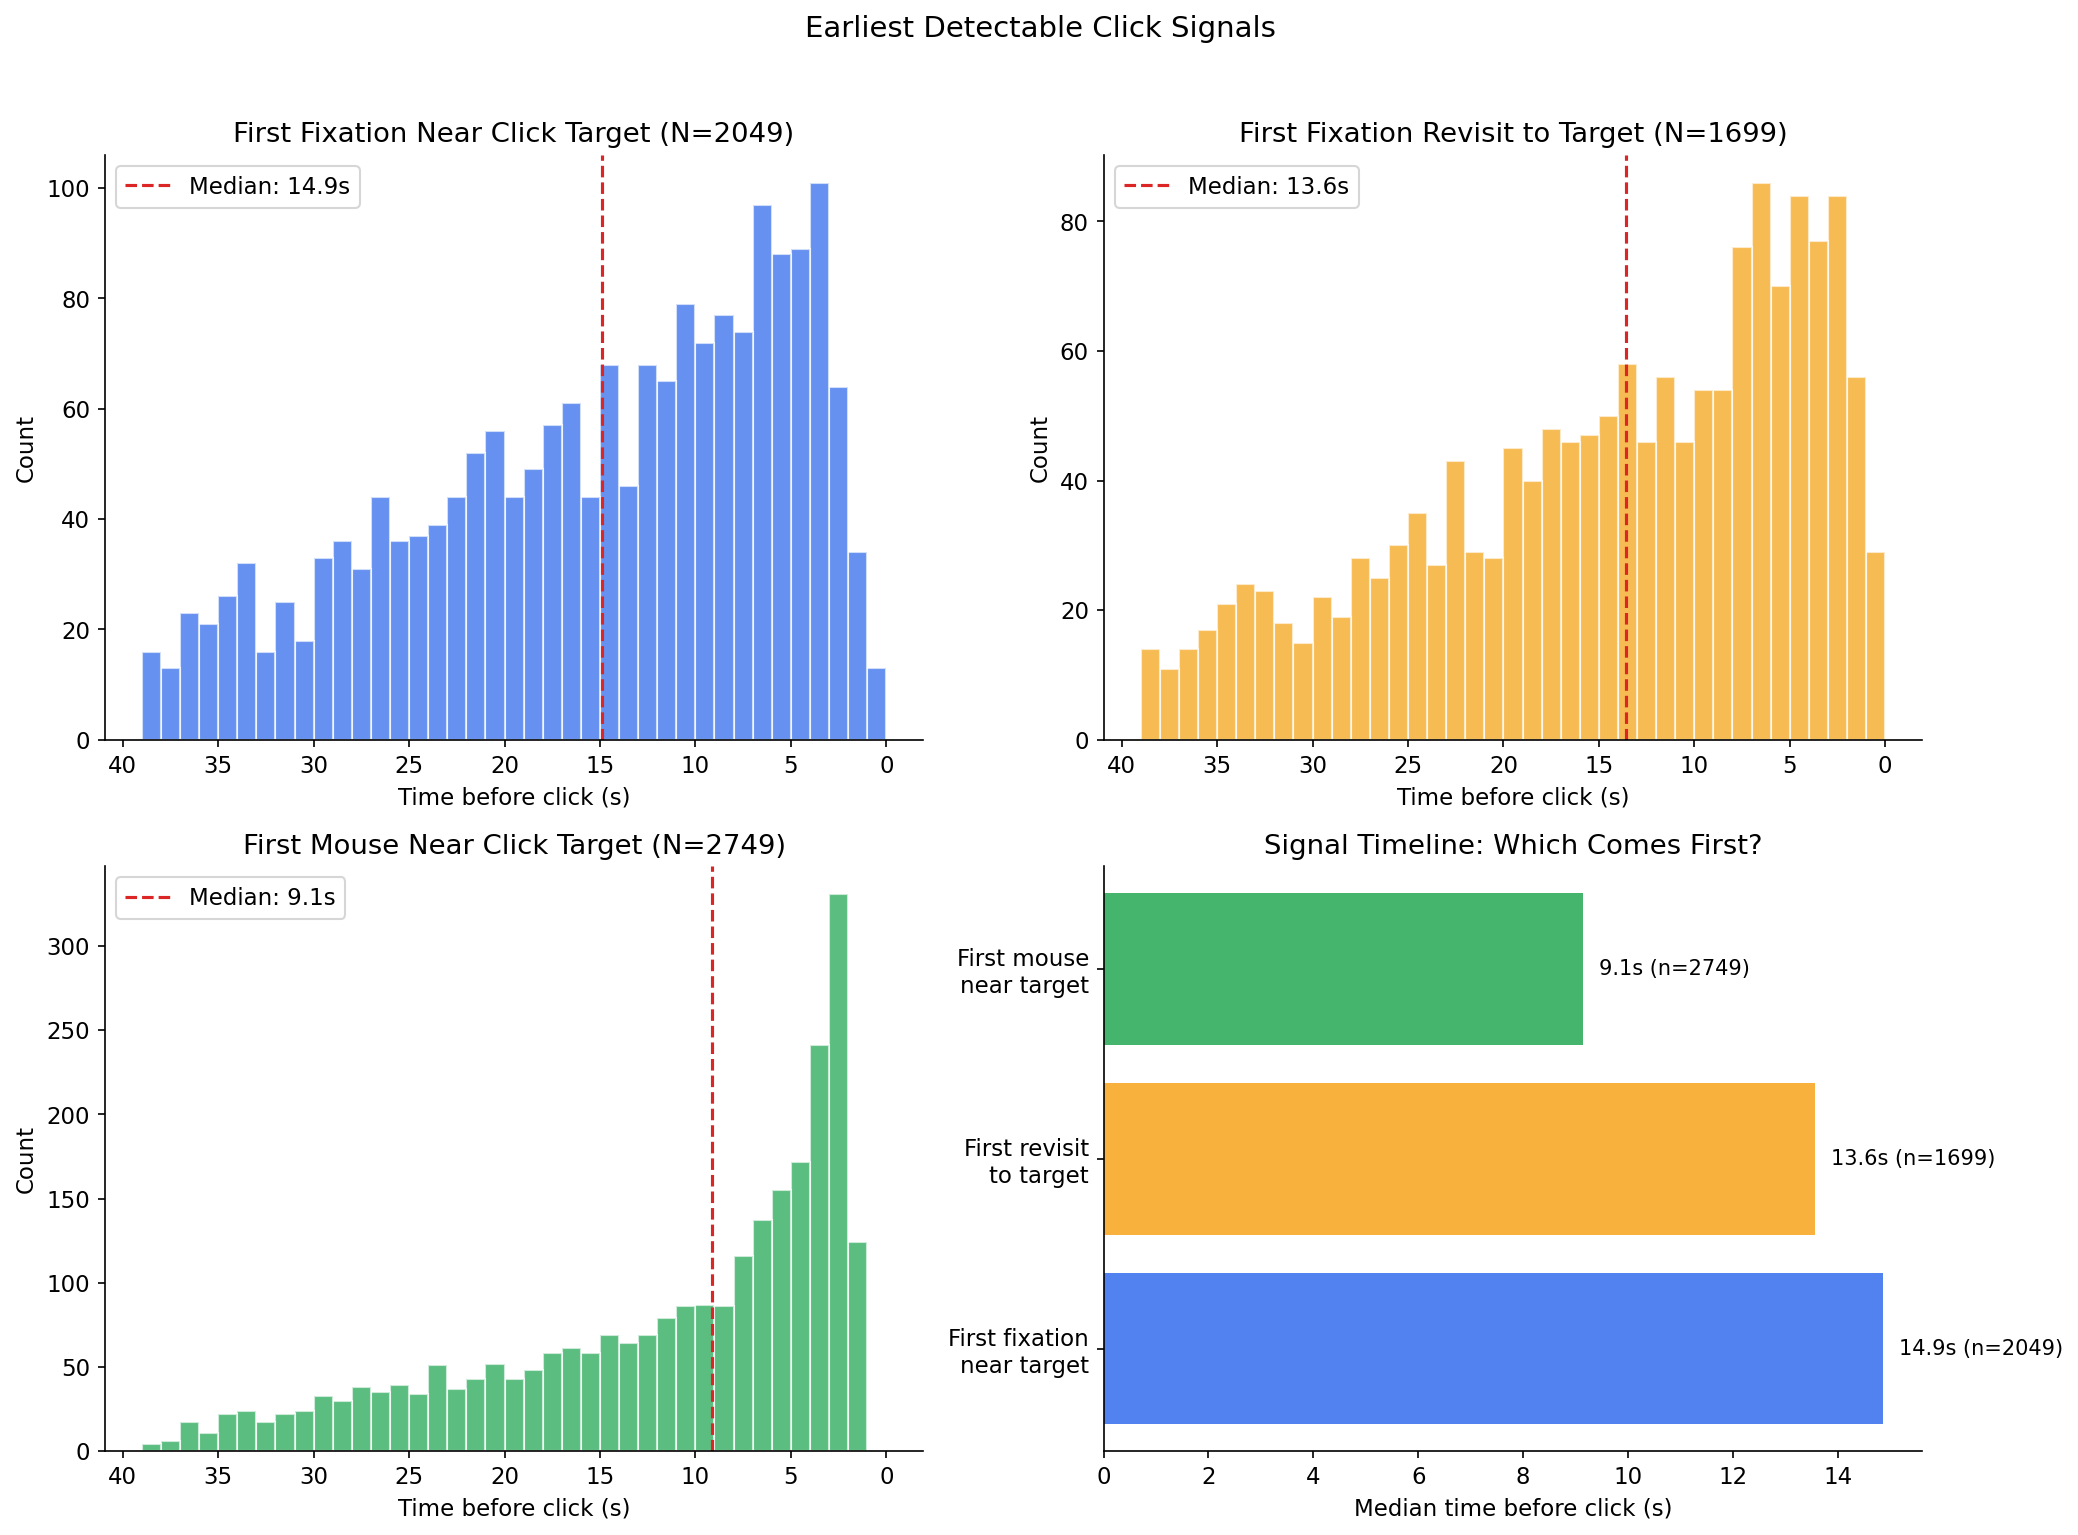


Signal onset (median seconds before click):
  First fixation near target: 14.9s
  First revisit to target:    13.6s
  First mouse near target:    9.1s

  Eye-to-revisit gap: 1.3s (time between first look and return)
  Eye-to-mouse gap:   5.7s (time between eye finding target and mouse arriving)


In [3]:
# Timeline: when does each signal first appear relative to the click?
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribution of first fixation on target (time before click)
ax = axes[0, 0]
first_fix_ttcs = [s['first_fix_near_target'] for s in signals if s['first_fix_near_target'] is not None]
ax.hist(first_fix_ttcs, bins=np.arange(0, 40, 1), color='#2563eb', alpha=0.7, edgecolor='white')
ax.set_xlabel('Time before click (s)')
ax.set_ylabel('Count')
ax.set_title(f'First Fixation Near Click Target (N={len(first_fix_ttcs)})')
ax.axvline(np.median(first_fix_ttcs), color='#dc2626', linestyle='--', label=f'Median: {np.median(first_fix_ttcs):.1f}s')
ax.legend()
ax.invert_xaxis()

# 2. Distribution of first revisit (eye returns to target after looking away)
ax = axes[0, 1]
revisit_ttcs = [s['first_revisit'] for s in signals if s['first_revisit'] is not None]
ax.hist(revisit_ttcs, bins=np.arange(0, 40, 1), color='#f59e0b', alpha=0.7, edgecolor='white')
ax.set_xlabel('Time before click (s)')
ax.set_ylabel('Count')
ax.set_title(f'First Fixation Revisit to Target (N={len(revisit_ttcs)})')
if revisit_ttcs:
    ax.axvline(np.median(revisit_ttcs), color='#dc2626', linestyle='--', label=f'Median: {np.median(revisit_ttcs):.1f}s')
    ax.legend()
ax.invert_xaxis()

# 3. First mouse near target
ax = axes[1, 0]
mouse_ttcs = [s['first_mouse_near'] for s in signals if s['first_mouse_near'] is not None]
ax.hist(mouse_ttcs, bins=np.arange(0, 40, 1), color='#16a34a', alpha=0.7, edgecolor='white')
ax.set_xlabel('Time before click (s)')
ax.set_ylabel('Count')
ax.set_title(f'First Mouse Near Click Target (N={len(mouse_ttcs)})')
if mouse_ttcs:
    ax.axvline(np.median(mouse_ttcs), color='#dc2626', linestyle='--', label=f'Median: {np.median(mouse_ttcs):.1f}s')
    ax.legend()
ax.invert_xaxis()

# 4. Signal timeline comparison — median onset of each signal
ax = axes[1, 1]
signal_names = []
signal_medians = []
signal_ns = []

for name, vals in [
    ('First fixation\nnear target', first_fix_ttcs),
    ('First revisit\nto target', revisit_ttcs),
    ('First mouse\nnear target', mouse_ttcs),
]:
    if vals:
        signal_names.append(name)
        signal_medians.append(np.median(vals))
        signal_ns.append(len(vals))

colors = ['#2563eb', '#f59e0b', '#16a34a'][:len(signal_names)]
bars = ax.barh(signal_names, signal_medians, color=colors, alpha=0.8)
ax.set_xlabel('Median time before click (s)')
ax.set_title('Signal Timeline: Which Comes First?')
for bar, m, n in zip(bars, signal_medians, signal_ns):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{m:.1f}s (n={n})', va='center', fontsize=10)

plt.suptitle('Earliest Detectable Click Signals', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('plot_early1_timeline.png', dpi=200, bbox_inches='tight')
plt.show()

# Key comparison
if first_fix_ttcs and revisit_ttcs:
    print(f"\nSignal onset (median seconds before click):")
    print(f"  First fixation near target: {np.median(first_fix_ttcs):.1f}s")
    print(f"  First revisit to target:    {np.median(revisit_ttcs):.1f}s")
    print(f"  First mouse near target:    {np.median(mouse_ttcs):.1f}s")
    gap = np.median(first_fix_ttcs) - np.median(revisit_ttcs)
    print(f"\n  Eye-to-revisit gap: {gap:.1f}s (time between first look and return)")
    gap2 = np.median(first_fix_ttcs) - np.median(mouse_ttcs)
    print(f"  Eye-to-mouse gap:   {gap2:.1f}s (time between eye finding target and mouse arriving)")